In [1]:
#import packages
import time
import numpy as np
from typing import *
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import plotly.graph_objects as go
from scipy.interpolate import splprep, splev
import csv
import os
from NIDAQ import USB6363
import nidaqmx
from nidaqmx.constants import AcquisitionType
from nidaqmx.constants import Edge
from src.DieTesterInstrument import *
from src.FirstLightController import *
from src.ChipAlignmentController import ChipAlignmentController
from src.NIDAQPowermeter import PowermeterSystem
from src.SoftwareFence import SoftwareFence
import SantecTunableLaser
print(dir(SantecTunableLaser))
#list ASRLs
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources(query ='?*') # to make sure all the Suruga stages are connected

['TSL', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'pyvisa', 'time']


('USB0::0x0957::0x3718::MY51350815::0::INSTR',
 'USB0::0x1313::0x8031::M01066988::0::INSTR',
 'TCPIP0::K-EXR608A-60117::hislip0::INSTR',
 'TCPIP0::K-EXR608A-60117::inst0::INSTR',
 'TCPIP0::K-EXR608A-60117::5025::SOCKET',
 'TCPIP0::K-N7749C-00104::inst0::INSTR',
 'TCPIP0::K-N7749C-00104::5025::SOCKET',
 'TCPIP0::K-N7749C-00104::hislip0::INSTR',
 'TCPIP0::K-N7786C-00222::inst0::INSTR',
 'TCPIP0::K-N7786C-00222::5025::SOCKET',
 'TCPIP0::K-N7786C-00222::hislip0::INSTR',
 'TCPIP0::K-N7742C-00112::inst0::INSTR',
 'TCPIP0::K-N7742C-00112::5025::SOCKET',
 'TCPIP0::K-N7742C-00112::hislip0::INSTR',
 'TCPIP0::K-N7776C-00505::inst0::INSTR',
 'TCPIP0::K-N7776C-00505::5025::SOCKET',
 'TCPIP0::K-N7776C-00505::hislip0::INSTR',
 'ASRL1::INSTR',
 'ASRL3::INSTR',
 'ASRL17::INSTR',
 'ASRL18::INSTR',
 'ASRL19::INSTR',
 'ASRL20::INSTR')

In [3]:
#@ Die Tester Stage and Powermeter + Motion I/O

try:
    stg.close()
    pm.close()
    time.sleep(1)
    del stg
    del pm
except:
    0

# stg = DieTesterStage(9, 11, 8, 10)
stg = DieTesterStage(17, 20, 18, 19)
# stg = DieTesterStage(19, 20, 21, 22) # before moving: 13, 15, 5, 4
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) # needs Dev1 for the raster to work

Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


In [4]:
# testing USB connection
TSL770 = SantecTunableLaser.TSL('TCPIP0::10.101.0.157::64000::SOCKET') # LAN
TSL770.timeout = 5000

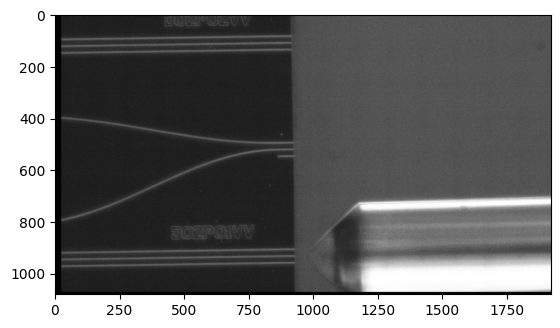

In [5]:
## OBS Virtual Camera (Make sure its on and that you have the correct name)
%matplotlib inline
def clear_interface():
    plt.close('all')
    clear_output(wait=True)

cap = RealtimeVideoCapture(1)  # Change to whatever index your OBS camera is. 
time.sleep(1)

clear_interface()
plt.imshow(cap.mean_capture(10, convert_to_grayscale=False))
plt.show()

In [6]:
flc = FirstLightController(pm, stg)
cac = ChipAlignmentController(stg, cap)
fence = SoftwareFence(stg, cap)

### CHIP ALIGNMENT

In [839]:
# CHIP ALIGNMENT
## Move chip (and camera) so that the top or bottom calibration patterns are visible in the camera, roughly in the middle.
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -80, wait=True)# -9000 (up) or 9000 (down) to move it

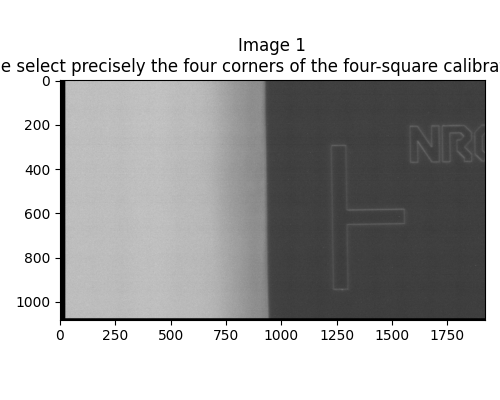

In [840]:
## Run to open template selection widget and draw a bounding box around the pattern or alignment mark.
%matplotlib widget

img = cap.mean_capture(20)
clear_interface()
cac.new_template_selection(img)

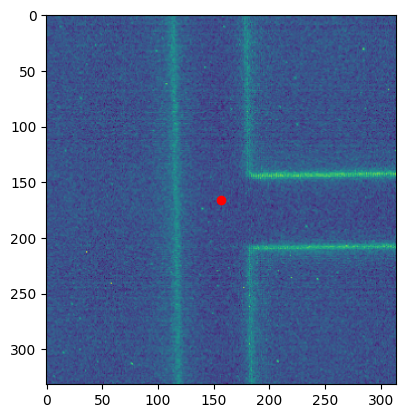

In [841]:
## Save the template to the alignment controller
%matplotlib inline

template_image = cac.generate_template(img)
clear_interface()
plt.imshow(template_image)
plt.scatter(template_image.shape[1] / 2, template_image.shape[0] / 2, c='r')
plt.show()

In [665]:
# move the chip to see the other alignment mark and bring it back
stg.set_speed('m', 9)
stg.move_relative('m', 'X',100, wait=True)# -10000 or 10000, TFLN 9000, b/w adjacent wvgs 6 um; wvg sets 381um
#remember to move it back and not to redefine the template

Starting Calibration Movement...
Calibration movement done. Starting main movement...
All images aquired. Moving back to starting position.
Matching calibration centers...
Generating visualization of calibration centers...
Calculating rotation...
Done. Optimal rotation is 0.2348 degrees.


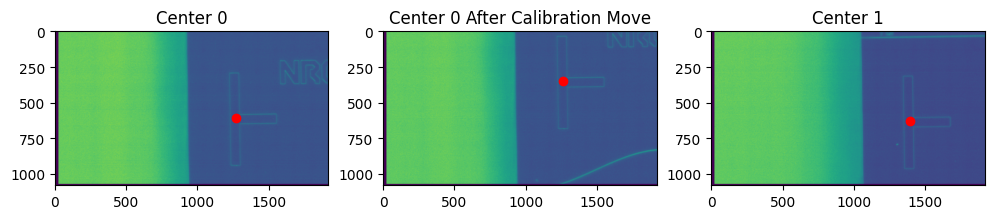

In [842]:
%matplotlib inline
## Select your movement values and perform chip alignment.
# Large movement should be roughly the length of the chip (1 cm works well), small calibration movement should be a few hundred microns.
#   - Make sure that the small movement doesn't bring your calibration pattern out of frame
# The sign of the movements should be positive for moving from top to bottom, and negative for moving bottom to top.


mainX = 9_300  # main movement (width of chip), 10_000 original
calX = 80  # calibration movement, 500 before
deg = cac.run_angle_calibration(mainX, calX, camera_focus_prompt=True) 

In [843]:
## If angle seems reasonable, rotate to align chip
# Check the pattern centers in the images for reasonableness
stg.move_relative_rotation(deg) # deg

In [849]:
# move the chip to first waveguide
stg.set_speed('m', 9)
stg.move_relative('m', 'X', 50, wait=True)


### Helper functions - no need to run unless the kernel restarts

In [7]:
# Convert NewFocus PD output voltage to power 
def pdToPow(x, g): # argument x is the photodiode output volts from tap
    # g is the gain setting
    R = 0.55 # responsivity, can interpolate the graph for more accurate values
    tap_pow = x/(g*R) # power in mW
    #act_pow = tap_pow*10*0.9*0.5 # 90/10 and 50/50 splitter output
    return tap_pow # in mW

def logPDtoPow(Vout):
    Vy = 0.3
    Iz = 100e-12
    Ipd = Iz * 10**(Vout/Vy)
    R = 0.9
    pow = Ipd/R
    return pow*1e3

def switch_route(route_no, output_port):
    switch.write('rout' + route_no + ':chan1 A,' + output_port)

def gaussian_fit_func(xy, a, x0, sigxsq, y0, sigysq):
    x = xy[:,0]
    y = xy[:,1]
    return a * np.exp(-((x-x0)**2/sigxsq + (y-y0)**2/sigysq))

def raster_fit(datapoints):

    xy_points = datapoints[:, 0:2]
    P_points = datapoints[:, 2]

    # fitting a 2d gaussian
    p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

    [fitparams, fitcov] = curve_fit(gaussian_fit_func, xy_points, P_points, p0, maxfev=5000)
    fitcov
    fit_gauss = gaussian_fit_func(xy_points, *fitparams)

    # fig = go.Figure()
    # fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=P_points,
    #                                 mode='markers', marker=dict(
    #                 size=2,          # Marker size in pixels
    #                 color='blue',      # Marker color
    #                 opacity=0.8,      # Transparency
    #                 symbol='circle'   # Marker shape
    #             )))
    # fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=fit_gauss, marker=dict(
    #                 size=2,          # Marker size in pixels
    #                 color='red',      # Marker color
    #                 opacity=0.8,      # Transparency
    #                 symbol='circle'   # Marker shape
    #             )))
    # fig.show()

    x0 = fitparams[1]
    y0 = fitparams[3]

    if np.abs(x0) > 3.5 or np.abs(y0) > 7: # for safety if the fit is wrong
        x0 = y0 = 0
    
    print(f"Moved to {[x0, y0]}")
    print('Max is: ', np.max(P_points))
    return x0, y0

def raster_scan(stage, broad_range):
    line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
    speed = 9# 7  

    if broad_range == True:
        commands = flc.pgen.generate_linear_spiral((20, 20), 40)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
    else:
        commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
    result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

    datapoints = result['datapoints']
    return datapoints

def parabola(x, a, b, c):
    return a*x + b* x**2 + c

def z_scan(stage, broad_range):
    if broad_range == True:
        commands = [
        ['Z', 1],#2 RECENTLY CHANGED
        ['Z', -5], #-4
        ]
    else:
        commands = [
        ['Z', 1],#2
        ['Z', -2], #-8
        ]
        
    line_numbers = [0, 1, 2] # left XY, right XY, all Z
    speed = 6 # increased speed from 2

    result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

    datapoints = result['datapoints']

    z_tun = datapoints[:,0]
    Pz_tun = datapoints[:,2]

    # fig = plt.figure('z_scan')
    # ax = fig.add_subplot(111)
    # plt.plot(z_tun, Pz_tun, 'o') # plotting for checking, remove in a loop
    
    # tck, u = splprep([z_tun, Pz_tun], s=40, k = 5)
    # new_points = splev(u, tck)
    # plt.plot(new_points[0], new_points[1])
    # # fig.show()
    
    # print(new_points[0][np.argmax(new_points[1])])

    # stg.move_relative(stage, 'z', new_points[0][np.argmax(new_points[1])], wait=True)

    # return new_points[0][np.argmax(new_points[1])]

    [fitparams, fitcov] = curve_fit(parabola, z_tun, Pz_tun) # p0
    fitcov
    fit_par = parabola(z_tun, *fitparams)

    # plt.plot(z_tun, fit_par)plotting for checking, remove in a loop
    print(z_tun[np.argmax(fit_par)])

    return z_tun[np.argmax(fit_par)]

def fine_tun():
    z_trans_l = z_scan('l', True) # False?
    # time.sleep(0.75)
    stg.move_relative('l', 'Z', z_trans_l)
    stage = 'l'
    raster_data = raster_scan(stage, False)
    x0, y0 = raster_fit(raster_data)
    stg.move_relative(stage, 'X', x0)
    stg.move_relative(stage, 'Y', y0)

    z_trans_r = z_scan('r', True)# False?
    # time.sleep(0.75)
    stg.move_relative('l', 'Z', z_trans_r)
    stage = 'r'
    raster_data = raster_scan(stage, False)
    x0, y0 = raster_fit(raster_data)
    stg.move_relative(stage, 'X', x0)
    stg.move_relative(stage, 'Y', y0)

    return raster_data, z_trans_l, z_trans_r

def prep_next_wvg(z_trans_l, z_trans_r, device_no):
    # stg.move_relative('l', 'z', -z_trans_l, wait=True)
    # stg.move_relative('r', 'z', -z_trans_r, wait=True)
    il = -100
    stg.set_speed('m', 9)
    if device_no%2 == 0:
        stg.move_relative('m', 'X', -(254-8), wait=True) 
    else:
        stg.move_relative('m', 'X', -(8), wait=True)

    # device_no+=1
    return device_no, il

### function for measuring and saving transfer function 

In [8]:
header = r'Tapvolt770(V),SHGvoltage(V),Trigger volt(V), Wavelength(um)'
def transfer_fn(folder_path, device_no):#, wvg_set):
    # ACTUAL TWM setup; continuous sweeping
    start_wavelength = 1500e-9
    stop_wavelength = 1620e-9
    sample_rate = 10000
    sweep_speed = 200  # nm/s - useful for 30 us, 200 ACTUAL
    sweep_range = stop_wavelength - start_wavelength
    sweep_time = sweep_range * 1e9 / sweep_speed  # seconds, factor of 1.5 given in the old code, required?
    n770 = int(sweep_time * sample_rate)
    samples = np.arange(n770)

    steps_770 = np.linspace(start_wavelength, stop_wavelength, n770)
    trigger_step = 100e-12

        # Configure TSL770 for sweeping

    TSL770.wavelength_start(start_wavelength)
    TSL770.wavelength_stop(stop_wavelength)

    # Note: trigger_step caps sweep speed; always set it first
    # TSL770.trigger_step(4e-12) # useful for 10 nm/s
    # TSL770.trigger_step(20e-12) # useful for 100 nm/s
    TSL770.trigger_step(trigger_step) # useful for 200 nm/s
    TSL770.sweep_speed(sweep_speed)
    TSL770.trigger_setting(1) # 1 - Time trigger; nonuniform wvl spacing, 0 - wavelength trigger
    TSL770.sweep_mode(1) # continuous sweep

    # Configure DAQ

    # # Add Digital input channels
    # daq.di_task = nidaqmx.Task()
    # daq.di_task.di_channels.add_di_chan("Dev2/Port1/Line5")
    daq.ai_task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source = "/Dev2/PFI5", trigger_edge=Edge.RISING)

    t_samp_daq = 1/sample_rate
    t_samp_770 = trigger_step * 1e9/sweep_speed
    daq.configure_sampling(sample_rate, n770)
    TSL770.wavelength(start_wavelength)

    time.sleep(0.6)  # Allow lasers to settle
    # print(f'570: {step_570 * 1e9:.2f} nm')

    # Measure data

    TSL770.sweep_state(1)
    daq.start()
    data = daq.read()
    daq.stop()

    raw_wavelength_data = TSL770.read_wavelength()
    t_daq = t_samp_daq * samples
    t_770 = t_samp_770 * np.arange(len(raw_wavelength_data))
    steps_770 = np.interp(t_daq, t_770, raw_wavelength_data)
    # print(data)
    # pout[i, :] = data[0][0]      # power
    # tap_570[i, :] = data[0][1]   # 570 tap
    # tap_770[i, :] = data[0][2]   # 770 tap
    # trigger_diagnostic[i, :] = data[0][3] 

    time.sleep(0.6)

    folder_name = folder_path + '/device_no_'

    # folder_name = folder_path + '/Transfer_function/'

    # # Create directories if they don't exist
    # os.makedirs(folder_path, exist_ok=True)
    
    plt.clf()
    plt.plot(steps_770, np.array(data[0][1])) # in daq configured sampling, /(3e4 * 0.45)
    plt.xlabel(r'Wavelength ($\mu$m)')
    # plt.ylabel('SHG power (mW)')
    plt.ylabel('PD output voltage (V)')
    plt.savefig(folder_name + str(device_no) +'.png')# + wvg_set

    dataT = np.reshape(data, (3, len(steps_770))).T
    data_new = np.column_stack((dataT, steps_770))
    np.savetxt(folder_name + str(device_no) + '.csv', data_new, delimiter = ',', header = header) #+ wvg_set 

In [9]:
# Initialize switch
# address = 'TCPIP0::10.101.0.199::5025::INSTR' # N7731A
address = 'USB0::0x0957::0x3718::MY51350815::INSTR' # N7731A
# address = 'USB0::0x0957::0x3718::MY51350266::INSTR' # N7734A 
# USB0::0x0957::0x3718::MY51350815::0::INSTR

rm = pyvisa.ResourceManager()
switch = rm.open_resource(address)
switch.timeout = 5000 

# Verify Connection to the switch
idn = switch.query('*IDN?')
print(f"Connected to: {idn}")

Connected to: Keysight Technologies, N7731A, MY51350815, 1.21



### loading input power calibration

In [205]:
# Interpolate to get the power in mW after the lensed fiber for a given tap output
# tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut770_aftBOA267mA.csv", delimiter = ',', skiprows= 1)
tap_data = np.loadtxt(r"characterization_data\lut_aftBOA_aftLensedFiber.csv", delimiter = ',', skiprows= 1)

idx = np.argmin(np.abs(tap_data[:,0] - 1.56e-6))
idx+=5 # to get the correct middle
inp_pow = tap_data[idx,2]*1e3 # scaling
print(inp_pow)

22.0


### COARSE FIBER ALIGNMENT MANUALLY

##### Move the left fiber ~ 2 um away from the chip

9000 to move it coarsely first and then finer steps

In [922]:
## Perform this for both the left and right stages. ('l' and 'r')
stage = 'l'
## Do whatever commands you need to move the left/right fiber into the frame and change 'z' towards the waveguide
stg.move_relative(stage, 'z', 10, wait=True)#moved 40, -30

#### Move the chip to bring the wavguide towards fiber position

In [913]:
# move the chip 
stg.set_speed('m', 9)
stg.move_relative('m', 'x', 10, wait=True)

### Bring the fiber in focus

In [ ]:
## Change 'y' to bring the fiber in focus
stage = 'l'
## Do whatever commands you need to move the left/right fiber into the frame and in focus.
stg.move_relative(stage, 'y', 2, wait=True)#moved 40, -30


#### Go to kinesis software and move the microscope to the other end of chip

5.9 mm : input side

0 mm : output side

#### Bring the right fiber towards the waveguide

9000 along 'z' to move it coarsely first and then finer steps

In [949]:
stg.move_relative('r', 'z', 2, wait=True)

#### Move the fiber along'x' if needed to center it with waveguide

In [940]:
stg.move_relative('r', 'x', -20, wait=True)

### Bring the fiber in focus

In [953]:
stg.move_relative('r', 'y', -1, wait=True)

#### Use fault detector to make sure right fiber height is aligned and adjust 'y' to get red light into waveguide

#### Run the below cell for the auto-alignment process. Fibers should be almost 2 um away from the chip

In [11]:
z_trans_r = z_trans_l = 2 # 50

FIRST LIGHT

In [12]:
import importlib
import src.FirstLightController
importlib.reload(src.FirstLightController)
from src.FirstLightController import *

flc = FirstLightController(pm, stg)

### raster scan - do separately for 'l' and 'r'

In [193]:
# Broad scan, femto detector
switch_route('1', '1')
ai_channel = 'ai0'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

### Broad scan, can make it small scan with generate_linear_spiral((5, 5), 10)
stage = 'r'
line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
speed = 7# 7                  # Speed setting from 0-9. Higher is only faster to a point.
# ai_channel = 'ai1'

broad_range = False
if broad_range == True:
    commands = flc.pgen.generate_linear_spiral((20, 20), 40)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
else:
    commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
# commands = flc.pgen.generate_linear_spiral((50, 50), 200)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = True)

datapoints = result['datapoints']

# Not plotting the distribution
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]
print(f"Maximum: {max_point}")

fig.show()

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.45item/s]


Returning to original position...
Fitting gaussian regression to datapoints...
Found optimal parameters.
Mean: [-0.00926887  0.03877573]
Cov: [[ 0.70301425 -0.0881516 ]
 [-0.0881516   0.75651766]]
Maximum: [-0.31111111  0.5       ]


In [194]:
# Move to the gaussian fit mean

mean = result['mean']
stg.move_relative(stage, 'X', mean[0])#mean[0])
stg.move_relative(stage, 'Y', mean[1])#mean[1])
print(f"Moved to {mean}")

Moved to [-0.00926887  0.03877573]


### relative adjustments of chip and fiber

This is necessary only after automatic chip alignment is done, if you need to recheck any particular waveguide that had saturated the silicon detector

In [110]:
# # move the chip to the next waveguide
stg.set_speed('m', 9)
# stg.move_relative('m', 'X',-8, wait=True) #381
stg.move_relative('m', 'X', 254, wait=True) #381

In [202]:
stg.move_relative('l', 'z', -10000) # -5
# stg.move_relative(stage, 'Y', -mean[1])#mean[1])

### z-translation - do separately for 'l' and 'r'

In [189]:
## Z fine-tuning
stage = 'r'
line_numbers = [0, 1, 2] # left XY, right XY, all Z
speed = 6

# Enter a list of relative commands manually, comes back to original position
commands = [
    ['Z', 2],#2
    ['Z', -6], #-8
]
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]

fig.show()

Starting motion...


Current Move: (Z, -6.0): 100%|██████████| 2/2 [00:00<00:00,  6.65item/s]


Returning to original position...


0.2


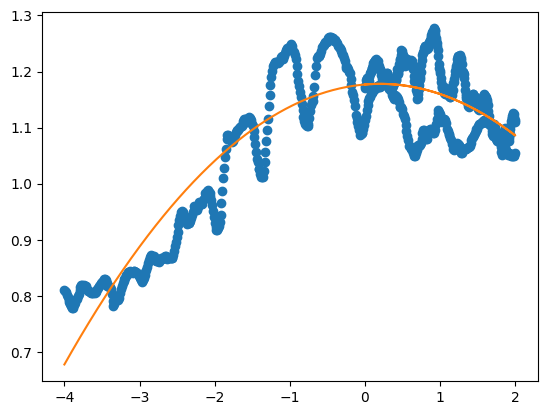

In [190]:
# do the same raster scan for 'r'
z_tun = datapoints[:,0]
Pz_tun = datapoints[:,2]

plt.plot(z_tun, Pz_tun, 'o')

def parabola(x, a, b, c):
    return a*x + b* x**2 + c

# fitting a 2d gaussian
# p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

[fitparams, fitcov] = curve_fit(parabola, z_tun, Pz_tun) # p0
fitcov
fit_par = parabola(z_tun, *fitparams)

plt.plot(z_tun, fit_par)
print(z_tun[np.argmax(fit_par)])
stg.move_relative(stage, 'Z', z_tun[np.argmax(fit_par)])

### Defining folder for saving, change chip folder - Important!!!!

In [73]:
# folder_dir = "C:/Users/Pooja/Documents/Pooja/OneDrive - NTT Research Inc/Documents/Die testing/Insertion_loss_transfer_function/TFLN08_SCG-1/"
folder_dir = "C:/Users/Pooja/Documents/Pooja/OneDrive - NTT Research Inc/Documents/Die testing/Insertion_loss_transfer_function/SCG002/"
# chip_no = input("Enter chip number: ").strip()
# folder_name = f"chip{chip_no}"

'''
New wafer measurement
'''
chip_no = 'C12D02'

folder_path = folder_dir + chip_no

# Create directories if they don't exist
os.makedirs(folder_path, exist_ok=True)

file_path = os.path.join(folder_path, "insertion_loss.csv")

with open(file_path, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Device no", "IL (dB)"])

#### One waveguide at a time - checking insertion loss

In [178]:
'''
Aligning at 1560 nm

'''

threshold = 0.02

# Broad scan, femto detector
switch_route('1', '1')
ai_channel = 'ai0'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

stage = 'r'
raster_data = raster_scan(stage, True)# actual true
if np.max(raster_data[:,2]) < threshold:
    x0, y0 = 0, 0
                # # move fibers back
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
else:
    x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0, wait=True)
stg.move_relative(stage, 'Y', y0, wait=True)

stage = 'l'
raster_data = raster_scan(stage, True)
x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0, wait=True)
stg.move_relative(stage, 'Y', y0, wait=True)

# Small scan, log detector
switch_route('1', '2')
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

# increasing z scan speed, don't need sleep anymore
z_trans = z_scan('l', True) 
stg.move_relative('l', 'Z', z_trans)
# z_trans_l= z_trans_l - 2 + z_trans
z_trans_l= z_trans
stage = 'l'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0
# --- Optionally save None or NaN for this waveguide ---
stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

z_trans = z_scan('r', True)
stg.move_relative('r', 'Z', z_trans)
# z_trans_r = z_trans_r - 2 + z_trans
z_trans_r= z_trans
stage = 'r'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

# fine_tun_data = fine_tun()
# raster_data = fine_tun_data[0]
# z_trans_l+= fine_tun_data[1]
# z_trans_r+= fine_tun_data[2]

il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow) # in dB, cross-check PD gain value
print('Insertion loss- ', il)

# not including Si PD raster scan if the second harmonic power is too low

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -20.0): 100%|██████████| 80/80 [00:11<00:00,  7.21item/s]


Returning to original position...
Moved to [np.float64(0.08949417667216505), np.float64(0.01126740980333534)]
Max is:  1.4330082651938651
Starting motion...


Current Move: (Y, -20.0): 100%|██████████| 80/80 [00:10<00:00,  7.41item/s]


Returning to original position...
Moved to [np.float64(0.06818491947915299), np.float64(0.050808530923164404)]
Max is:  1.3416178231618923
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


...

Returning to original position...
Moved to [np.float64(0.18057717496561235), np.float64(0.06545511301879246)]
Max is:  2.080304823657271
Starting motion...


Current Move: (Z, -5.0): 100%|██████████| 2/2 [00:00<00:00,  6.65item/s]


Returning to original position...
-0.18736383442265803
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:02<00:00,  8.70item/s]


Returning to original position...
Moved to [np.float64(0.03347640446259238), np.float64(-0.00169087753754235)]
Max is:  2.089315183162602
Insertion loss-  -13.322812463861908


### Skip the next three blocks 

In [180]:
device_no = 4

### Initialize daq, do transfer function measurement and save

Connected to: NI DAQ, Dev2, USB-6363 (BNC)
200


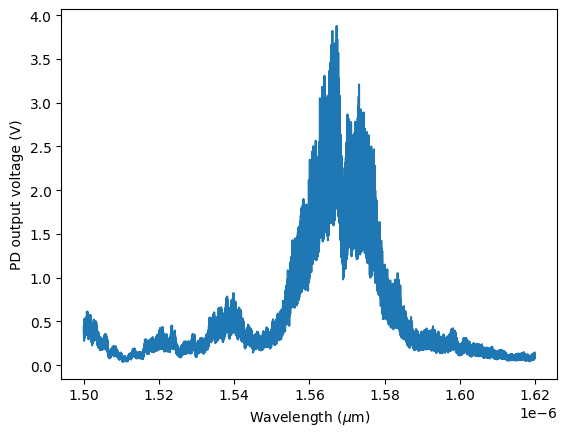

In [197]:
# change to Si PD before TWM
switch_route('1', '3')
ai_channel = 'ai2'

daq = USB6363()
# Add Analog input channels, 4 - Si, 5 - TSL770
daq.ai_task = nidaqmx.Task()
daq.ai_task.ai_channels.add_ai_voltage_chan("Dev2/ai5, Dev2/ai4, Dev2/ai0")

transfer_fn(folder_path, device_no)

daq.close()

#### check if laser wavelength is 1560 nm; changing laser wavelength to 1560 nm

In [201]:
TSL770.wavelength(1560e-9)
time.sleep(0.5)

### Running all waveguides on a chip 

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -20.0): 100%|██████████| 80/80 [00:10<00:00,  7.40item/s]


Returning to original position...
Moved to [np.float64(-0.019146824904752762), np.float64(-0.011322055885528913)]
Max is:  1.5895627578458642
Starting motion...


Current Move: (Y, -20.0): 100%|██████████| 80/80 [00:10<00:00,  7.55item/s]


Returning to original position...
Moved to [np.float64(0.03673185166338255), np.float64(-0.021198056591498267)]
Max is:  1.5029992107707564
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


...

Current Move: (Z, -5.0): 100%|██████████| 2/2 [00:00<00:00,  6.70item/s]


Returning to original position...
0.1612200435729847
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:02<00:00,  8.64item/s]


Returning to original position...
Moved to [np.float64(0.11141616106515714), np.float64(-0.07159982544389477)]
Max is:  2.1205296469067334
66, Insertion loss-  -12.282330339057525
Connected to: NI DAQ, Dev2, USB-6363 (BNC)
200


c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\twm.venv\Lib\site-packages\nidaqmx\task\_task.py:128: DaqResourceWarning: Task of name "_unnamedTask<156>" was not explicitly closed before it was destructed. Resources on the task device may still be reserved.
  warnings.warn(
c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\twm.venv\Lib\site-packages\nidaqmx\task\_task.py:128: DaqResourceWarning: Task of name "_unnamedTask<157>" was not explicitly closed before it was destructed. Resources on the task device may still be reserved.
  warnings.warn(
c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\twm.venv\Lib\site-packages\nidaqmx\task\_task.py:128: DaqResourceWarning: Task of name "_unnamedTask<158>" was not explicitly closed before it was destructed. Resources on the task device may still be reserved.
  warnings.warn(
c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\twm.venv\Lib\site-packages\nidaqmx\task\_task.py:128: DaqResourceWarning: Task of name "_unnamedTask<159>" was not e

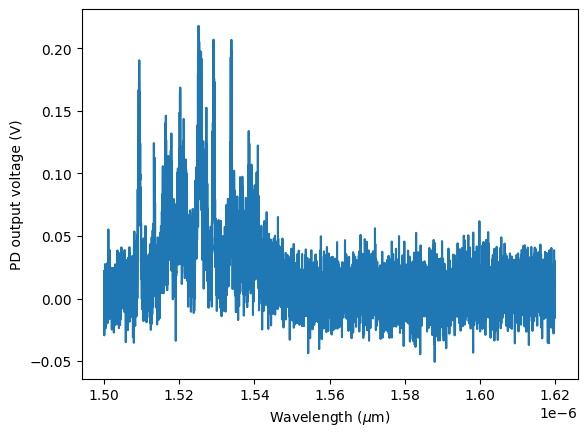

In [74]:
with open(file_path, mode="a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
  
    for i in range(1, 66):
        device_no = i+1
        # il, z_trans_l, z_trans_r = align(device_no)
        # print(str(device_no) + ', Insertion loss- ', il)
        # writer.writerow([device_no, il])

        '''
        Aligning at 1560 nm

        '''

        threshold = 0.02

        # Broad scan, femto detector
        switch_route('1', '1')
        ai_channel = 'ai0'
        pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
        flc = FirstLightController(pm, stg) 

        stage = 'r'
        raster_data = raster_scan(stage, True)# actual true
        if np.max(raster_data[:,2]) < threshold:
            x0, y0 = 0, 0
                        # # move fibers back
            device_no, il = prep_next_wvg(z_trans_l, z_trans_r, device_no)
            writer.writerow([device_no, il])
            device_no+=1
            continue
        else:
            x0, y0 = raster_fit(raster_data)
        stg.move_relative(stage, 'X', x0, wait=True)
        stg.move_relative(stage, 'Y', y0, wait=True)

        stage = 'l'
        raster_data = raster_scan(stage, True)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no, il = prep_next_wvg(z_trans_l, z_trans_r, device_no)
            x0, y0 = 0, 0
            writer.writerow([device_no, il])
            device_no+=1
            continue
        stg.move_relative(stage, 'X', x0, wait=True)
        stg.move_relative(stage, 'Y', y0, wait=True)

        # Small scan, log detector
        switch_route('1', '2')
        ai_channel = 'ai1'
        pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
        flc = FirstLightController(pm, stg) 

        # increasing z scan speed, don't need sleep anymore
        z_trans = z_scan('l', True) 
        stg.move_relative('l', 'Z', z_trans)
        # z_trans_l= z_trans_l - 2 + z_trans
        z_trans_l= z_trans
        # Added z scan once more
        z_trans = z_scan('l', True) 
        stg.move_relative('l', 'Z', z_trans)
        # z_trans_l= z_trans_l - 2 + z_trans
        z_trans_l= z_trans

        stage = 'l'
        raster_data = raster_scan(stage, False)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no, il = prep_next_wvg(z_trans_l, z_trans_r, device_no)
            x0, y0 = 0, 0
            writer.writerow([device_no, il])
            device_no+=1
            continue
        # --- Optionally save None or NaN for this waveguide ---
        stg.move_relative(stage, 'X', x0)
        stg.move_relative(stage, 'Y', y0)

        z_trans = z_scan('r', True)
        stg.move_relative('r', 'Z', z_trans)
        # z_trans_r = z_trans_r - 2 + z_trans
        z_trans_r= z_trans
        # Added z scan once more
        z_trans = z_scan('r', True)
        stg.move_relative('r', 'Z', z_trans)
        # z_trans_r = z_trans_r - 2 + z_trans
        z_trans_r= z_trans

        stage = 'r'
        raster_data = raster_scan(stage, False)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no, il = prep_next_wvg(z_trans_l, z_trans_r, device_no)
            x0, y0 = 0, 0
            writer.writerow([device_no, il])
            device_no+=1
            continue

        stg.move_relative(stage, 'X', x0)
        stg.move_relative(stage, 'Y', y0)

        # fine_tun_data = fine_tun()
        # raster_data = fine_tun_data[0]
        # z_trans_l+= fine_tun_data[1]
        # z_trans_r+= fine_tun_data[2]

        il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow) # in dB, cross-check PD gain value
        writer.writerow([device_no, il])
        print(str(device_no) + ', Insertion loss- ', il)

#

        # ---------transfer function measurement
        # change to Si PD before TWM
        switch_route('1', '3')
        ai_channel = 'ai2'
        time.sleep(0.1) # time for the switch?
        daq = USB6363()
        # Add Analog input channels, 4 - Si, 5 - TSL770
        daq.ai_task = nidaqmx.Task()
        daq.ai_task.ai_channels.add_ai_voltage_chan("Dev2/ai5, Dev2/ai4, Dev2/ai0")

        transfer_fn(folder_path, device_no)

        daq.close()
        #-------------
        TSL770.wavelength(1560e-9)
        time.sleep(0.5)

        #cMove back the fibers and go to the next waveguide
        # made z_trans_l = z_trans_r = 2
        # if (z_trans_l > 1):
        #     stg.move_relative('l', 'z', -z_trans_l, wait=True)
        # else:
        #     z_trans_l = 2
        #     stg.move_relative('l', 'z', -z_trans_l, wait=True)

        # if z_trans_r > 1:
        #     stg.move_relative('r', 'z', -z_trans_r, wait=True)
        # else:
        #     z_trans_r = 2
        #     stg.move_relative('r', 'z', -z_trans_r, wait=True)

        # # # move the chip to the next waveguide
        '''
        +: going down
        -: up
        '''

        stg.set_speed('m', 9)
        if device_no%2 == 0:
            stg.move_relative('m', 'X', -(254-8), wait=True)
            # stg.move_relative('r', 'y', -5)# added
            # stg.move_relative('l', 'y', -5)# # added
        else:
            stg.move_relative('m', 'X', -(8), wait=True)
        


#### move the chip back to device 66

In [75]:
# # move the chip to the next waveguide
stg.set_speed('m', 9)
stg.move_relative('m', 'X', 254-8, wait=True) #381

### Once the data is all saved, close file and close devices

In [ ]:
f.close()
TSL770.close()
switch.close()

#### Move back the fibers by 10000

In [199]:
stg.move_relative('r', 'z', -10000, wait=True)

In [200]:
stg.move_relative('l', 'z', -10000, wait=True)

#### convert SHG voltages to power

In [ ]:
gain = 3e4
R = 0.45 # V/mW
shg_pow = shg_v/(gain * R)

# calculating conversion efficiency
pf = inp_pow*1e-3 * 10**-0.75 # IL approx 15 dB throughput
pshg = 2.296e-9/10**-0.8 # newly measured 8 dB
l = 6e-3
pshg/(pf**2 * l**2) * 100 # in %